<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/Copy_of_05_ml_price_based_more.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

import xgboost as xgb


from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import os
import time

### Download from Yahoo Finance

In [ ]:
TICKERS = ['NVDA', 'AMD', 'TSM','QQQ', '^VIX', '^TNX']
START_DATE = '2021-01-01'
END_DATE = '2026-02-05'

stocks = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    group_by='ticker',
    auto_adjust=True,
    prepost=True,
    threads=True,
    progress=False
)
stocks.head(3)


In [ ]:
display(stocks.info())

#### There are 30 columns and 1278 rows

### Save the main file, and divide it by price and volume and save them in 2 other files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Flatten columns for easier use later

stocks_flat = stocks.copy()
stocks_flat.columns = ['_'.join(col) for col in stocks_flat.columns.values]

stocks_flat.head()

In [ ]:
# Since ^VTX and ^TNX are an index and yield series and not traded security, they do not have trading volume (Volume column is 0)
# We will use 'Close' only and drop these columns

cols_to_drop = ['^VIX_Volume', '^TNX_Volume']
stocks_flat_clean = stocks_flat.drop(columns=cols_to_drop)

stocks_flat_clean.to_csv(
    '/content/drive/MyDrive/stocks/stocks_raw_2021_2026_clean.csv',
    index=True
)

print("Saved: stock_raw_2021_2026_clean.csv")
stocks_flat_clean
print(stocks_flat_clean.columns)

In [ ]:
# updated -- ^ is replaced, column names are updated to lowercase
all_stocks_clean = stocks_flat_clean.copy()
all_stocks_clean.columns = all_stocks_clean.columns.str.replace('^', '').str.lower()
all_stocks_clean

display(all_stocks_clean.columns)
all_stocks_clean.head()

all_stocks_clean.to_csv(
    '/content/drive/MyDrive/stocks/all_stocks_raw_2021_2026.csv',
    index =True
)
print("Saved: all_stocks_clean_2021_2026.csv")
df = all_stocks_clean.copy()
df

#### The time frame of the dataset is: 2021-01-04 to 2026-02-04.  There are 28 columns, 1278 rows and no null values.

### Feature Engineering

#### NVDA-Only Features

In [ ]:
# ---------- PRICE FEATURES ----------
# Lagged prices (autoregressive features)

df['nvda_lag1_price'] = df['nvda_close'].shift(1)
df['nvda_lag2_price'] = df['nvda_close'].shift(2)
df['nvda_lag3_price'] = df['nvda_close'].shift(3)
df['nvda_lag5_price'] = df['nvda_close'].shift(5)
df['nvda_lag10_price'] = df['nvda_close'].shift(10)
df['nvda_lag20_price'] = df['nvda_close'].shift(20)

df['nvda_lag1_high_price'] = df['nvda_high'].shift(1)
df['nvda_lag2_low_price'] = df['nvda_low'].shift(2)
# Lagged Volumes
df['nvda_lag1_volume'] = df['nvda_volume'].shift(1)
df['nvda_lag2_volume'] = df['nvda_volume'].shift(2)
df['nvda_lag3_volume'] = df['nvda_volume'].shift(3)
df['nvda_lag5_volume'] = df['nvda_volume'].shift(5)
df['nvda_lag10_volume'] = df['nvda_volume'].shift(10)
df['nvda_lag20_volume'] = df['nvda_volume'].shift(20)

# Moving Avg (Different timeframe trends indicators)
df['nvda_roll2_price'] = df['nvda_close'].rolling(2).mean().shift(1)
df['nvda_roll3_price'] = df['nvda_close'].rolling(3).mean().shift(1)
df['nvda_roll5_price'] = df['nvda_close'].rolling(5).mean().shift(1)
df['nvda_roll10_price'] = df['nvda_close'].rolling(10).mean().shift(1)
df['nvda_roll20_price'] = df['nvda_close'].rolling(20).mean().shift(1)

# Distance from a longer moving average
df['nvda_roll2_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll2_price']
df['nvda_roll3_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll3_price']
df['nvda_roll5_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll5_price']
df['nvda_roll10_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll10_price']
df['nvda_roll20_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll20_price']

# How much is price fluctuating?
# Pirce Std - Magnitude Clustering
df['nvda_price_std2'] = df['nvda_close'].rolling(2).std().shift(1)
df['nvda_price_std3'] = df['nvda_close'].rolling(3).std().shift(1)
df['nvda_price_std5'] = df['nvda_close'].rolling(5).std().shift(1)   # Short-term price
df['nvda_price_std10'] = df['nvda_close'].rolling(10).std().shift(1)
df['nvda_price_std20'] = df['nvda_close'].rolling(20).std().shift(1) # Longer-term price

# Return Std - Relative Price Volatility Regime
df['nvda_volatility2'] = df['nvda_close'].pct_change().rolling(2).std().shift(1)
df['nvda_volatility3'] = df['nvda_close'].pct_change().rolling(3).std().shift(1)
df['nvda_volatility5'] = df['nvda_close'].pct_change().rolling(5).std().shift(1)
df['nvda_volatility10'] = df['nvda_close'].pct_change().rolling(10).std().shift(1)
df['nvda_volatility20'] = df['nvda_close'].pct_change().rolling(20).std().shift(1)

# MACD (Moving Average Convergence Divergence)
df['nvda_ema2'] = df['nvda_close'].ewm(span=2, adjust=False).mean().shift(1)
df['nvda_ema3'] = df['nvda_close'].ewm(span=3, adjust=False).mean().shift(1)
df['nvda_ema5'] = df['nvda_close'].ewm(span=5, adjust=False).mean().shift(1)
df['nvda_ema10'] = df['nvda_close'].ewm(span=10, adjust=False).mean().shift(1)
df['nvda_ema20'] = df['nvda_close'].ewm(span=20, adjust=False).mean().shift(1)

# Price Changes
df['nvda_lag1_return'] = df['nvda_close'].pct_change().shift(1)
df['nvda_lag2_return'] = df['nvda_close'].pct_change().shift(2)
df['nvda_lag3_return'] = df['nvda_close'].pct_change().shift(3)
df['nvda_lag5_return'] = df['nvda_close'].pct_change().shift(5)
df['nvda_lag10_return'] = df['nvda_close'].pct_change().shift(10)
df['nvda_lag20_return'] = df['nvda_close'].pct_change().shift(20)

# Trading activity signals
df['nvda_volume_ma2'] = df['nvda_volume'].rolling(2).mean().shift(1)
df['nvda_volume_ma3'] = df['nvda_volume'].rolling(3).mean().shift(1)
df['nvda_volume_ma5'] = df['nvda_volume'].rolling(5).mean().shift(1)
df['nvda_volume_ma20'] = df['nvda_volume'].rolling(20).mean().shift(1)
df['nvda_volume_ma30'] = df['nvda_volume'].rolling(30).mean().shift(1)

df['nvda_price_volume'] = df['nvda_close'].shift(1) * df['nvda_volume'].shift(1)  # Dollar volume
df['nvda_price_volume_ma2'] = df['nvda_price_volume'].rolling(2).mean().shift(1)
df['nvda_price_volume_ma3'] = df['nvda_price_volume'].rolling(3).mean().shift(1)
df['nvda_price_volume_ma5'] = df['nvda_price_volume'].rolling(5).mean().shift(1)
df['nvda_price_volume_ma10'] = df['nvda_price_volume'].rolling(10).mean().shift(1)
df['nvda_price_volume_ma20'] = df['nvda_price_volume'].rolling(20).mean().shift(1)
df['nvda_price_volume_ma30'] = df['nvda_price_volume'].rolling(30).mean().shift(1)

# High-Low range (shifted to avoid data leakage)
df['nvda_high_low_range'] = (df['nvda_high'].shift(1) - df['nvda_low'].shift(1))
df['nvda_high_low_pct'] = ((df['nvda_high'] - df['nvda_low']) / df['nvda_close']).shift(1)

# Indicators
# RSI (Relative Strength Index)
delta = df['nvda_close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['nvda_rsi'] = 100 - (100 / (1 + rs))
df['nvda_rsi'] = df['nvda_rsi'].shift(1)  # Avoid look-ahead bias

# MACD
exp1 = df['nvda_close'].ewm(span=5, adjust=False).mean()
exp2 = df['nvda_close'].ewm(span=10, adjust=False).mean()
df['nvda_macd'] = exp1 - exp2
df['nvda_macd'] = df['nvda_macd'].shift(1)

# Price Momentum
df['nvda_momentum1'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(2)
df['nvda_momentum2'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(3)
df['nvda_momentum3'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(4)
df['nvda_momentum5'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(6)
df['nvda_momentum10'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(11)

df['mom5_x_std2'] = df['nvda_momentum5'] * df['nvda_price_std2']
df['mom5_x_std3'] = df['nvda_momentum5'] * df['nvda_price_std3']
df['mom5_x_std5'] = df['nvda_momentum5'] * df['nvda_price_std5']
df['mom5_x_std10'] = df['nvda_momentum5'] * df['nvda_price_std10']
df['mom5_x_std20'] = df['nvda_momentum5'] * df['nvda_price_std20']

# Calendar Features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_month'] = df.index.day

df = df.copy()
df = df.sort_index()
df.head()
df['t'] = np.arange(len(df))


display(df.head())
print()
display(df.tail())
display(df.shape)

#### After feature-engineered, the timeframe is now from: 03-30-2021 to 12-19-2025. There are 17 columns and 1179 rows.

## Peason Correlation by NVDA Closing Price

In [ ]:
# Feature used for corr() chart purpose
df['y_30'] = df['nvda_close'].shift(-30)

# df_heatmap=df.corr().sort_values(by='y_30', key= abs, ascending=False).round(2)
# df_heatmap.head(60)

corr_matrix = df.corr()

# Sort by absolute correlation with y_30
sorted_corr = corr_matrix.loc[
    corr_matrix['y_30'].abs().sort_values(ascending=False).index
]

# Move y_30 column to the front
cols = ['y_30'] + [col for col in sorted_corr.columns if col != 'y_30']
df_heatmap = sorted_corr[cols]
df_heatmap.head(60)

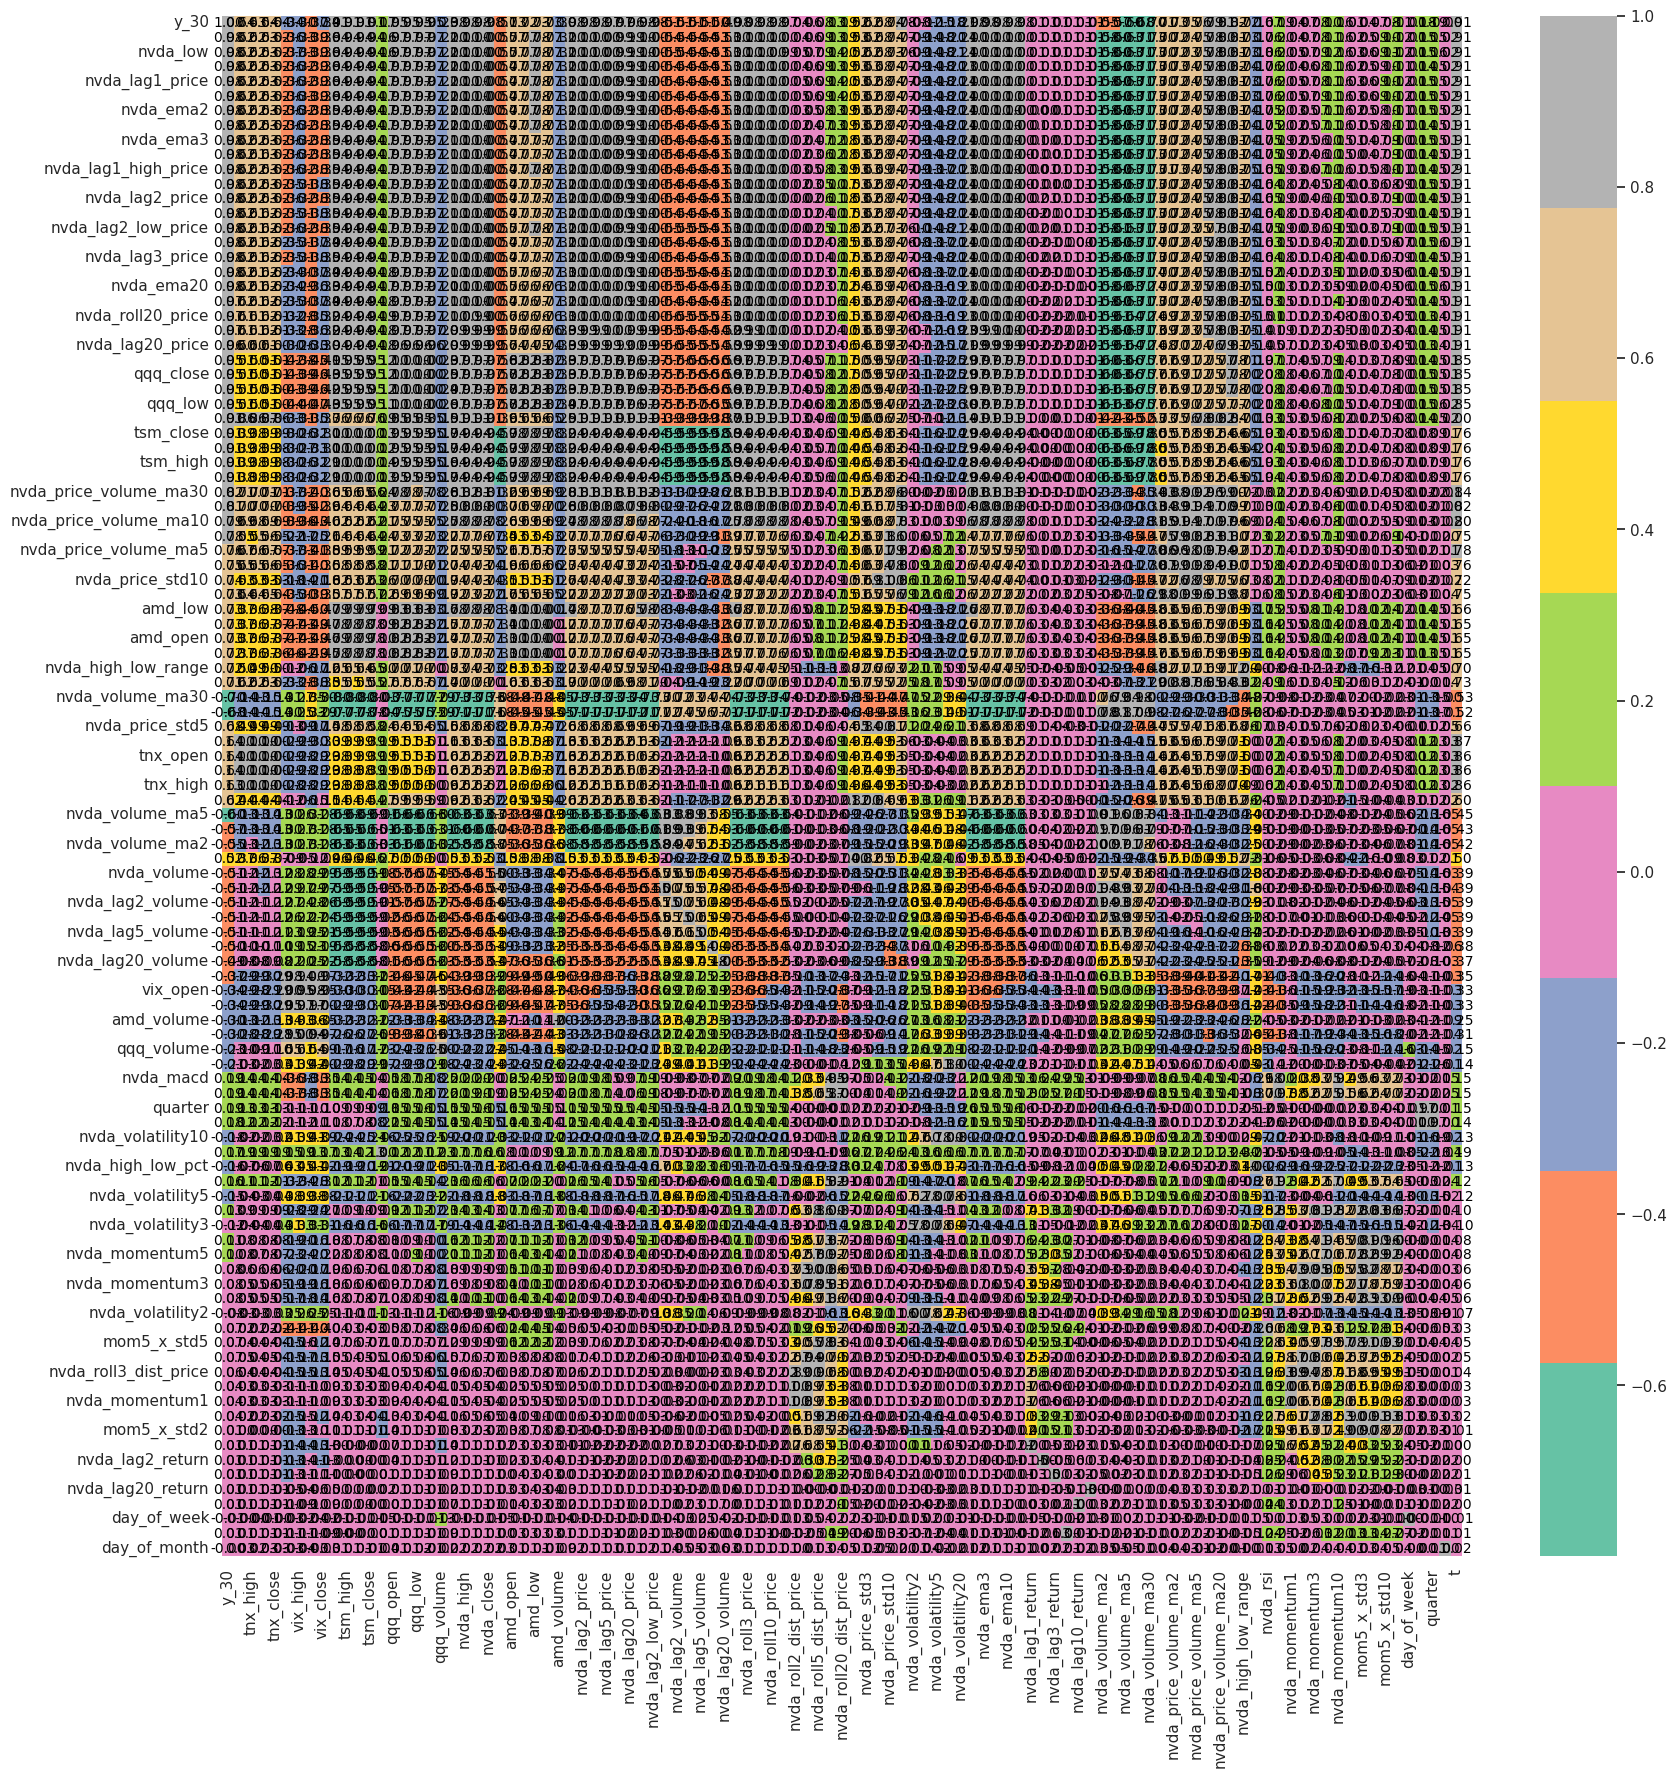

In [10]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(20,20))
sns.heatmap(df_heatmap, annot=True, cmap='Set2', annot_kws={'fontsize': 10, 'color': 'black'}, fmt='.2f')

### Time-Based Train-Test-Split

In [11]:
split_date = pd.to_datetime('2025-02-03') # first business date in Feb, 2025

#### Make a metric function

In [12]:
# updated
def evaluate_direct_price_model(
    df,
    feature_cols,
    horizon,
    split_date,
    model,
    scale=False
):

    df_model = df.copy()

    # Create dynamic target
    df_model['y'] = df_model['nvda_close'].shift(-horizon)

    # Keep only needed columns
    df_model = df_model[feature_cols + ['y']]

    # Drop NaNs safely
    df_model = df_model.dropna()

    # Split
    train = df_model[df_model.index < split_date]
    test  = df_model[df_model.index >= split_date]

    X_train = train[feature_cols]
    y_train = train['y']

    X_test  = test[feature_cols]
    y_test  = test['y']

    # Optional scaling (for Lasso / Ridge)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    # Fit model
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results = {
        "Horizon": horizon,
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
        "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
    }

    return results, model, test.index, y_test, y_pred_test

#     return results, model, test.index, y_test, y_pred_test


In [13]:
# updated old
# def evaluate_direct_price_model(
#     df,
#     feature_cols,
#     horizon,
#     split_date,
#     model,
#     scale=False
# ):

#     df_model = df.copy()

#     # Create dynamic target
#     df_model['y'] = df_model['nvda_close'].shift(-horizon)

#     # Keep only needed columns
#     df_model = df_model[feature_cols + ['y']]

#     # Drop NaNs safely
#     df_model = df_model.dropna()

#     # Split
#     train = df_model[df_model.index < split_date]
#     test  = df_model[df_model.index >= split_date]

#     X_train = train[feature_cols]
#     y_train = train['y']

#     X_test  = test[feature_cols]
#     y_test  = test['y']

#     # Optional scaling (for Lasso / Ridge)
#     if scale:
#         scaler = StandardScaler()
#         X_train = scaler.fit_transform(X_train)
#         X_test  = scaler.transform(X_test)

#     # Fit model
#     model.fit(X_train, y_train)

#     y_pred_train = model.predict(X_train)
#     y_pred_test  = model.predict(X_test)

#     results = {
#         "Horizon": horizon,
#         "Train_MAE": mean_absolute_error(y_train, y_pred_train),
#         "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
#         "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
#         "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
#         "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
#         "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
#     }

#     return results, model, test.index, y_test, y_pred_test

### Liner Regression (NVDA-Only Model)

In [14]:
# updated

X_cols_uni = [
'nvda_lag1_price',
# 'nvda_lag2_price',
# 'nvda_lag3_price',
# 'nvda_lag5_price',  #added
# 'nvda_lag10_price',
# 'nvda_lag20_price',

# # Lagged Volumes
# 'nvda_lag1_volume',
'nvda_lag2_volume',
# 'nvda_lag3_volume',
# 'nvda_lag5_volume',
# 'nvda_lag10_volume',
# 'nvda_lag20_volume',

# 'nvda_lag1_high_price',
# 'nvda_lag2_low_price',


# # Moving Avg (Different timeframe trends indicators)
# 'nvda_roll2_price',
# 'nvda_roll3_price',
# 'nvda_roll5_price', #added
# 'nvda_roll10_price',
# 'nvda_roll20_price',

# 'nvda_roll2_dist_price',
'nvda_roll3_dist_price', #(not sure yet, it improves 1 day and 5 days by little)
# 'nvda_roll5_dist_price',
# 'nvda_roll10_dist_price',
# 'nvda_roll20_dist_price',


# # How much is price fluctuating?
'nvda_price_std2',
# 'nvda_price_std3',
# 'nvda_price_std5',  # Short-term price   added and removed volality3d
# 'nvda_price_std10',
# 'nvda_price_std20', # Longer-term price

# Price Regime Volatility
'nvda_volatility2',
'nvda_volatility3',
'nvda_volatility5',
'nvda_volatility10',
'nvda_volatility20',

# # MACD (Moving Average Convergence Divergence)
'nvda_ema2', #deleted
# 'nvda_ema3',
# 'nvda_ema5',  # 1st try vs nvda_roll5_price
# 'nvda_ema10',
# 'nvda_ema20',

# # Price Changes
# 'nvda_lag1_return',
# 'nvda_lag2_return', # deleted
# 'nvda_lag3_return',
# 'nvda_lag5_return',
# 'nvda_lag10_return',
# 'nvda_lag20_return',


# # Trading activity signals

# 'nvda_volume_ma2',
# 'nvda_volume_ma3',
# 'nvda_volume_ma5',
'nvda_volume_ma20',
# 'nvda_volume_ma30',
# 'nvda_price_volume', # Dollar volume
# 'nvda_price_volume_ma1',
# 'nvda_price_volume_ma2',
# 'nvda_price_volume_ma3',
# 'nvda_price_volume_ma10',
# 'nvda_price_volume_ma20',

# # High-Low range (shifted to avoid data leakage)
# 'nvda_high_low_range',
# 'nvda_high_low_pct',

# # Indicators
## RSI (Relative Strength Index)
'nvda_rsi' ,  # Avoid look-ahead bias  # deleted

# # MACD
# 'nvda_macd',

# # # Price Momentum
# 'nvda_momentum2',
# 'nvda_momentum3',
'nvda_momentum5',
# 'nvda_momentum10',


# 'mom5_x_std2',
# 'mom5_x_std3',
# 'mom5_x_std5',
'mom5_x_std10',
# 'mom5_x_std20',

# Calendar Features
# 'day_of_week',
# 'month' ,
# 'quarter' ,
# 'day_of_month',
  't',
]



,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.725595,4.019574,2.830935,5.187057,0.039410,0.027156
1,5,2.941264,6.581790,4.634418,8.377437,0.067723,0.044766
2,10,3.862728,8.467278,5.934625,10.559019,0.091592,0.057587
3,20,5.199403,11.594978,7.796615,13.702247,0.124850,0.080214
4,30,6.333816,14.039819,9.521466,16.983331,0.149959,0.096295


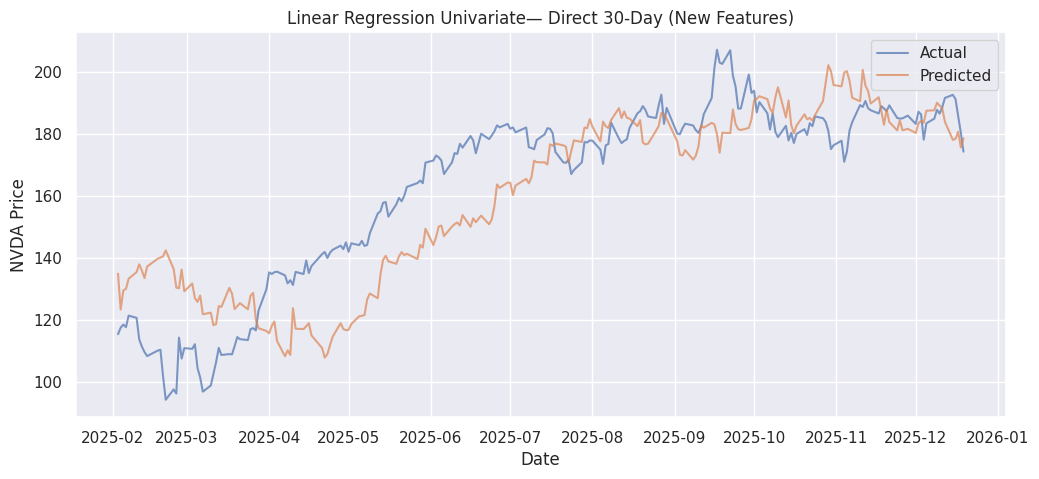

In [15]:
# Horizons (Various timeframes to test)
horizons = [1, 5, 10, 20, 30]
results_lr_uni = []

for h in horizons:

    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model=LinearRegression(),
        feature_cols=X_cols_uni,
        horizon=h,
        split_date=split_date,
        scale=False
    )

    results_lr_uni.append(metrics)

price_lr_uni_df = pd.DataFrame(results_lr_uni)
display(price_lr_uni_df)

print()

plt.figure(figsize=(12,5))
plt.plot(test_idx, y_test, label='Actual', alpha=0.7)
plt.plot(test_idx, y_pred, label='Predicted', alpha=0.7)
plt.title('Linear Regression Univariate— Direct 30-Day (New Features)')
plt.xlabel('Date')
plt.ylabel('NVDA Price')
plt.legend()
plt.show()

#### Multivarite Feature Engineer

In [16]:
# Multivariate Feature Engineer
# ---------- PRICE FEATURES ----------
# Lagged prices (autoregressive features)

df['nvda_lag1_price'] = df['nvda_close'].shift(1)
df['nvda_lag2_price'] = df['nvda_close'].shift(2)
df['nvda_lag3_price'] = df['nvda_close'].shift(3)
df['nvda_lag5_price'] = df['nvda_close'].shift(5)
df['nvda_lag10_price'] = df['nvda_close'].shift(10)
df['nvda_lag20_price'] = df['nvda_close'].shift(20)

df['nvda_lag1_high_price'] = df['nvda_high'].shift(1)
df['nvda_lag2_low_price'] = df['nvda_low'].shift(2)
# Lagged Volumes
df['nvda_lag1_volume'] = df['nvda_volume'].shift(1)
df['nvda_lag2_volume'] = df['nvda_volume'].shift(2)
df['nvda_lag3_volume'] = df['nvda_volume'].shift(3)
df['nvda_lag5_volume'] = df['nvda_volume'].shift(5)
df['nvda_lag10_volume'] = df['nvda_volume'].shift(10)
df['nvda_lag20_volume'] = df['nvda_volume'].shift(20)

# Moving Avg (Different timeframe trends indicators)
df['nvda_roll2_price'] = df['nvda_close'].rolling(2).mean().shift(1)
df['nvda_roll3_price'] = df['nvda_close'].rolling(3).mean().shift(1)
df['nvda_roll5_price'] = df['nvda_close'].rolling(5).mean().shift(1)
df['nvda_roll10_price'] = df['nvda_close'].rolling(10).mean().shift(1)
df['nvda_roll20_price'] = df['nvda_close'].rolling(20).mean().shift(1)

# Distance from a longer moving average
df['nvda_roll2_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll2_price']
df['nvda_roll3_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll3_price']
df['nvda_roll5_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll5_price']
df['nvda_roll10_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll10_price']
df['nvda_roll20_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll20_price']

# How much is price fluctuating?
# Pirce Std - Magnitude Clustering
df['nvda_price_std2'] = df['nvda_close'].rolling(2).std().shift(1)
df['nvda_price_std3'] = df['nvda_close'].rolling(3).std().shift(1)
df['nvda_price_std5'] = df['nvda_close'].rolling(5).std().shift(1)   # Short-term price
df['nvda_price_std10'] = df['nvda_close'].rolling(10).std().shift(1)
df['nvda_price_std20'] = df['nvda_close'].rolling(20).std().shift(1) # Longer-term price

# Return Std - Relative Price Volatility Regime
df['nvda_volatility2'] = df['nvda_close'].pct_change().rolling(2).std().shift(1)
df['nvda_volatility3'] = df['nvda_close'].pct_change().rolling(3).std().shift(1)
df['nvda_volatility5'] = df['nvda_close'].pct_change().rolling(5).std().shift(1)
df['nvda_volatility10'] = df['nvda_close'].pct_change().rolling(10).std().shift(1)
df['nvda_volatility20'] = df['nvda_close'].pct_change().rolling(20).std().shift(1)

# MACD (Moving Average Convergence Divergence)
df['nvda_ema2'] = df['nvda_close'].ewm(span=2, adjust=False).mean().shift(1)
df['nvda_ema3'] = df['nvda_close'].ewm(span=3, adjust=False).mean().shift(1)
df['nvda_ema5'] = df['nvda_close'].ewm(span=5, adjust=False).mean().shift(1)
df['nvda_ema10'] = df['nvda_close'].ewm(span=10, adjust=False).mean().shift(1)
df['nvda_ema20'] = df['nvda_close'].ewm(span=20, adjust=False).mean().shift(1)

# Price Changes
df['nvda_lag1_return'] = df['nvda_close'].pct_change().shift(1)
df['nvda_lag2_return'] = df['nvda_close'].pct_change().shift(2)
df['nvda_lag3_return'] = df['nvda_close'].pct_change().shift(3)
df['nvda_lag5_return'] = df['nvda_close'].pct_change().shift(5)
df['nvda_lag10_return'] = df['nvda_close'].pct_change().shift(10)
df['nvda_lag20_return'] = df['nvda_close'].pct_change().shift(20)

# Trading activity signals
df['nvda_volume_ma2'] = df['nvda_volume'].rolling(2).mean().shift(1)
df['nvda_volume_ma3'] = df['nvda_volume'].rolling(3).mean().shift(1)
df['nvda_volume_ma5'] = df['nvda_volume'].rolling(5).mean().shift(1)
df['nvda_volume_ma20'] = df['nvda_volume'].rolling(20).mean().shift(1)
df['nvda_volume_ma30'] = df['nvda_volume'].rolling(30).mean().shift(1)

df['nvda_price_volume'] = df['nvda_close'].shift(1) * df['nvda_volume'].shift(1)  # Dollar volume
df['nvda_price_volume_ma2'] = df['nvda_price_volume'].rolling(2).mean().shift(1)
df['nvda_price_volume_ma3'] = df['nvda_price_volume'].rolling(3).mean().shift(1)
df['nvda_price_volume_ma5'] = df['nvda_price_volume'].rolling(5).mean().shift(1)
df['nvda_price_volume_ma10'] = df['nvda_price_volume'].rolling(10).mean().shift(1)
df['nvda_price_volume_ma20'] = df['nvda_price_volume'].rolling(20).mean().shift(1)
df['nvda_price_volume_ma30'] = df['nvda_price_volume'].rolling(30).mean().shift(1)

# High-Low range (shifted to avoid data leakage)
df['nvda_high_low_range'] = (df['nvda_high'].shift(1) - df['nvda_low'].shift(1))
df['nvda_high_low_pct'] = ((df['nvda_high'] - df['nvda_low']) / df['nvda_close']).shift(1)

# Indicators
# RSI (Relative Strength Index)
delta = df['nvda_close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['nvda_rsi'] = 100 - (100 / (1 + rs))
df['nvda_rsi'] = df['nvda_rsi'].shift(1)  # Avoid look-ahead bias

# MACD
exp1 = df['nvda_close'].ewm(span=5, adjust=False).mean()
exp2 = df['nvda_close'].ewm(span=10, adjust=False).mean()
df['nvda_macd'] = exp1 - exp2
df['nvda_macd'] = df['nvda_macd'].shift(1)

# Price Momentum
df['nvda_momentum1'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(2)
df['nvda_momentum2'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(3)
df['nvda_momentum3'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(4)
df['nvda_momentum5'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(6)
df['nvda_momentum10'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(11)

df['mom5_x_std2'] = df['nvda_momentum5'] * df['nvda_price_std2']
df['mom5_x_std3'] = df['nvda_momentum5'] * df['nvda_price_std3']
df['mom5_x_std5'] = df['nvda_momentum5'] * df['nvda_price_std5']
df['mom5_x_std10'] = df['nvda_momentum5'] * df['nvda_price_std10']
df['mom5_x_std20'] = df['nvda_momentum5'] * df['nvda_price_std20']

# Calendar Features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_month'] = df.index.day


####
df['amd_lag1_price'] = df['amd_close'].shift(1)
# df['tsm_close'] = df['tsm_close']
df['tsm_lag1_close'] = df['tsm_close'].shift(1)

# volume regime

# stock rolling trends
df['qqq_roll3_price'] = df['qqq_close'].rolling(3).mean().shift(1)
df['qqq_roll5_price'] = df['qqq_close'].rolling(5).mean().shift(1)

df['amd_roll3_price'] = df['amd_close'].rolling(3).mean().shift(1)
df['amd_roll5_price'] = df['amd_close'].rolling(5).mean().shift(1)

df['tsm_roll3_price'] = df['tsm_close'].rolling(3).mean().shift(1)
df['tsm_roll5_price'] = df['tsm_close'].rolling(5).mean().shift(1)
df['tsm_roll10_price'] = df['tsm_close'].rolling(10).mean().shift(1)
df['tsm_roll20_price'] = df['tsm_close'].rolling(10).mean().shift(1)

df['amd_ema10'] = df['amd_close'].ewm(span=10, adjust=False).mean().shift(1)
df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)

# risk & rates (7-day and 14-day lag as chosen)
df['vix_lag7_price'] = df['vix_close'].shift(7)
df['vix_lag14_price'] = df['vix_close'].shift(14)
df['tnx_lag7_price'] = df['tnx_close'].shift(7)
df['tnx_lag14_price'] = df['tnx_close'].shift(14)

df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
df['tsm_price_std3'] = df['tsm_close'].rolling(3).std().shift(1)
df['tsm_price_std5'] = df['tsm_close'].rolling(5).std().shift(1)   # Short-term price
df['tsm_price_std10'] = df['tsm_close'].rolling(10).std().shift(1)
df['tsm_price_std20'] = df['tsm_close'].rolling(20).std().shift(1)

# Return tsm Std - Relative Price Volatility Regime
df['tsm_volatility2'] = df['tsm_close'].pct_change().rolling(2).std().shift(1)
df['tsm_volatility3'] = df['tsm_close'].pct_change().rolling(3).std().shift(1)
df['tsm_volatility5'] = df['tsm_close'].pct_change().rolling(5).std().shift(1)
df['tsm_volatility10'] = df['tsm_close'].pct_change().rolling(10).std().shift(1)
df['tsm_volatility20'] = df['tsm_close'].pct_change().rolling(20).std().shift(1)


df = df.copy()
df = df.sort_index()
df['t'] = np.arange(len(df))

display(df.head())
print()
display(df.tail())
display(df.shape)

/tmp/ipython-input-148895/3481495989.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_volatility2'] = df['tsm_close'].pct_change().rolling(2).std().shift(1)
/tmp/ipython-input-148895/3481495989.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tsm_volatility3'] = df['tsm_close'].pct_change().rolling(3).std().shift(1)
/tmp/ipython-input-148895/3481495989.py:157: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

,tnx_open,tnx_high,tnx_low,tnx_close,vix_open,vix_high,vix_low,vix_close,tsm_open,tsm_high,...,tsm_price_std2,tsm_price_std3,tsm_price_std5,tsm_price_std10,tsm_price_std20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.935,0.953,0.907,0.917,23.040001,29.190001,22.559999,26.969999,102.502923,104.921353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.937,0.963,0.927,0.955,26.940001,28.600000,24.799999,25.340000,103.367308,105.702974,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,1.000,1.054,1.000,1.042,25.480000,26.770000,22.139999,25.070000,104.691455,107.027128,...,0.695740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,1.056,1.088,1.054,1.071,23.670000,23.910000,22.250000,22.370001,109.739806,113.050214,...,1.846633,1.858115,NaN,NaN,NaN,0.011034,NaN,NaN,NaN,NaN
2021-01-08,1.088,1.126,1.075,1.105,22.430000,23.340000,21.420000,21.559999,115.781309,116.130737,...,3.784299,4.059490,NaN,NaN,NaN,0.017789,0.020567,NaN,NaN,NaN


,tnx_open,tnx_high,tnx_low,tnx_close,vix_open,vix_high,vix_low,vix_close,tsm_open,tsm_high,...,tsm_price_std2,tsm_price_std3,tsm_price_std5,tsm_price_std10,tsm_price_std20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,4.247,4.271,4.223,4.227,16.040001,19.740000,16.020000,16.879999,339.799988,343.739990,...,2.800137,4.819172,5.653623,6.826300,11.411123,0.003689,0.012268,0.011466,0.023572,0.021918
2026-01-30,4.247,4.261,4.236,4.241,18.719999,19.270000,16.670000,17.440001,335.420013,339.899994,...,1.944544,2.029290,3.801133,6.559051,9.775088,0.013957,0.013163,0.013962,0.023285,0.022028
2026-02-02,4.236,4.281,4.231,4.275,19.950001,19.959999,16.080000,16.340000,330.760010,344.200012,...,6.356883,6.140166,4.893653,6.289222,7.821654,0.013041,0.019094,0.017321,0.020193,0.023127
2026-02-03,4.290,4.300,4.266,4.274,16.160000,20.370001,16.049999,18.000000,345.070007,347.049988,...,7.636745,5.784113,4.657271,6.144349,7.793098,0.041824,0.030264,0.022983,0.023163,0.021406
2026-02-04,4.268,4.290,4.261,4.275,17.629999,21.240000,17.469999,18.639999,335.600006,338.799988,...,3.966859,5.401355,4.810195,5.657751,7.555995,0.034723,0.031651,0.023619,0.018385,0.021826


(1278, 131)

In [17]:
# updated
# df_model = df.copy()

# train = df_model[df_model.index < split_date]
# test  = df_model[df_model.index >= split_date]

X_cols_mul = [
'nvda_lag1_price',
'nvda_lag2_price',
# 'nvda_lag3_price',
# 'nvda_lag5_price',  #added
# 'nvda_lag10_price',
# 'nvda_lag20_price',

# # # Lagged Volumes
# 'nvda_lag1_volume',
# 'nvda_lag2_volume',
# 'nvda_lag3_volume',
# 'nvda_lag5_volume',
# 'nvda_lag10_volume',
# 'nvda_lag20_volume',

# 'nvda_lag1_high_price',
# 'nvda_lag2_low_price',


# # # Moving Avg (Different timeframe trends indicators)
# 'nvda_roll2_price',
'nvda_roll3_price',
# 'nvda_roll5_price', #added
# 'nvda_roll10_price',
# 'nvda_roll20_price',

# 'nvda_roll2_dist_price',
# 'nvda_roll3_dist_price', #(not sure yet, it improves 1 day and 5 days by little)
# 'nvda_roll5_dist_price',
# 'nvda_roll10_dist_price',
# 'nvda_roll20_dist_price',


# # # How much is price fluctuating?
'nvda_price_std2',
# 'nvda_price_std3',
# 'nvda_price_std5',  # Short-term price   added and removed volality3d
# 'nvda_price_std10',
# 'nvda_price_std20', # Longer-term price

# # Price Regime Volatility
# 'nvda_volatility2',
'nvda_volatility3',
# 'nvda_volatility5',
# 'nvda_volatility10',
# 'nvda_volatility20',

# # # MACD (Moving Average Convergence Divergence)
# 'nvda_ema2', #deleted
# 'nvda_ema3',
# 'nvda_ema5',  # 1st try vs nvda_roll5_price
# 'nvda_ema10',
'nvda_ema20',

# # Price Changes
# 'nvda_lag1_return',
# 'nvda_lag2_return', # deleted
# 'nvda_lag3_return',
'nvda_lag5_return',
# 'nvda_lag10_return',
# 'nvda_lag20_return',


# # # Trading activity signals

# 'nvda_volume_ma2',
# 'nvda_volume_ma3',
# 'nvda_volume_ma5',
# 'nvda_volume_ma20',
'nvda_volume_ma30',
# 'nvda_price_volume', # Dollar volume

# 'nvda_price_volume_ma2',
# 'nvda_price_volume_ma3',
# 'nvda_price_volume_ma10',
# 'nvda_price_volume_ma20',

# # # High-Low range (shifted to avoid data leakage)
'nvda_high_low_range',
# 'nvda_high_low_pct',

# # # Indicators
# ## RSI (Relative Strength Index)
# 'nvda_rsi' ,  # Avoid look-ahead bias  # deleted

# # # MACD
'nvda_macd',

# # # Price Momentum
# 'nvda_momentum2',
# 'nvda_momentum3',
# 'nvda_momentum5',
'nvda_momentum10',

# 'mom5_x_std2',
# 'mom5_x_std3',
# 'mom5_x_std5',
# 'mom5_x_std10',
'mom5_x_std20',

# 'amd_lag1_price',
'tsm_close',
# 'tsm_lag1_close',

# # # volume regime

# # # stock rolling trends
# 'qqq_roll3_price',
'qqq_roll5_price',
# 'amd_roll3_price',
# 'amd_roll5_price',

# 'tsm_roll3_price',
# 'tsm_roll5_price',
'tsm_roll10_price',
# 'tsm_roll20_price',
# 'amd_ema10' ,
'tsm_ema20' ,


# # risk & rates (7-day and 14-day lag as chosen)
# 'vix_lag7_price',
# 'vix_lag14_price',
# 'tnx_lag7_price',
'tnx_lag14_price',

# 'tsm_price_std2',
# 'tsm_price_std3',
# 'tsm_price_std5',
# 'tsm_price_std10',
'tsm_price_std20',

'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',

# # # Calendar Features
# 'day_of_week',
# 'month' ,
# 'quarter' ,
# 'day_of_month',
't'
]



In [18]:
# Horizons (Various timeframes to test)
horizons = [1, 5, 10, 20, 30]
results_lr_mul = []

for h in horizons:

    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        model = LinearRegression(),
        feature_cols=X_cols_mul,
        horizon=h,
        split_date=split_date,
        scale=False
    )

    results_lr_mul.append(metrics)

price_lr_mul_df = pd.DataFrame(results_lr_mul)
display(price_lr_mul_df)

print()

# plt.figure(figsize=(12,5))
# plt.plot(test_idx, y_test, label='Actual', alpha=0.7)
# plt.plot(test_idx, y_pred, label='Predicted', alpha=0.7)
# plt.title('Linear Regression Univariate— Direct 30-Day (New Features)')
# plt.xlabel('Date')
# plt.ylabel('NVDA Price')
# plt.legend()
# plt.show()

,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.704849,3.937320,2.722728,5.090461,0.041072,0.026197
1,5,2.946105,6.711115,4.585482,8.425208,0.067542,0.045233
2,10,3.841527,9.636713,5.634978,11.868997,0.097854,0.066098
3,20,5.257645,13.209460,7.473859,16.052729,0.133614,0.092402
4,30,6.433245,14.348802,9.212685,17.654521,0.172854,0.100629


### Interpretation

#### As expected, forecast error increases as the horizon expands.

- 5-day horizon shows lowest error (RMSE = 8.67 test).
- 10- and 20-day horizons show moderate degradation.
- 30-day horizon exhibits the largest test error.

#### This confirms that longer forecast horizons accumulate uncertainty and are harder to predict accurately.

#### The increase appears approximately monotonic, suggesting stable model behavior rather than overfitting.

### Visual Interpretation:

#### The predicted values track overall trend but lag during regime shifts.
#### Error widens during high-volatility periods.


## Expanded Multivariate Logistic Regression Model (Cross-Asset Signals)
### Rebuild the Model

### Feature Engineering with Multiple New Series

In [19]:
# ---------- PRICE FEATURES ----------
# Lagged prices (autoregressive features)

df['nvda_lag1_price'] = df['nvda_close'].shift(1)
df['nvda_lag2_price'] = df['nvda_close'].shift(2)
df['nvda_lag3_price'] = df['nvda_close'].shift(3)
df['nvda_lag5_price'] = df['nvda_close'].shift(5)
df['nvda_lag10_price'] = df['nvda_close'].shift(10)
df['nvda_lag20_price'] = df['nvda_close'].shift(20)

df['nvda_lag1_high_price'] = df['nvda_high'].shift(1)
df['nvda_lag2_low_price'] = df['nvda_low'].shift(2)
# Lagged Volumes
df['nvda_lag1_volume'] = df['nvda_volume'].shift(1)
df['nvda_lag2_volume'] = df['nvda_volume'].shift(2)
df['nvda_lag3_volume'] = df['nvda_volume'].shift(3)
df['nvda_lag5_volume'] = df['nvda_volume'].shift(5)
df['nvda_lag10_volume'] = df['nvda_volume'].shift(10)
df['nvda_lag20_volume'] = df['nvda_volume'].shift(20)

# Moving Avg (Different timeframe trends indicators)
df['nvda_roll2_price'] = df['nvda_close'].rolling(2).mean().shift(1)
df['nvda_roll3_price'] = df['nvda_close'].rolling(3).mean().shift(1)
df['nvda_roll5_price'] = df['nvda_close'].rolling(5).mean().shift(1)
df['nvda_roll10_price'] = df['nvda_close'].rolling(10).mean().shift(1)
df['nvda_roll20_price'] = df['nvda_close'].rolling(20).mean().shift(1)

# Distance from a longer moving average
df['nvda_roll2_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll2_price']
df['nvda_roll3_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll3_price']
df['nvda_roll5_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll5_price']
df['nvda_roll10_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll10_price']
df['nvda_roll20_dist_price'] = df['nvda_close'].shift(1) - df['nvda_roll20_price']

# How much is price fluctuating?
# Pirce Std - Magnitude Clustering
df['nvda_price_std2'] = df['nvda_close'].rolling(2).std().shift(1)
df['nvda_price_std3'] = df['nvda_close'].rolling(3).std().shift(1)
df['nvda_price_std5'] = df['nvda_close'].rolling(5).std().shift(1)   # Short-term price
df['nvda_price_std10'] = df['nvda_close'].rolling(10).std().shift(1)
df['nvda_price_std20'] = df['nvda_close'].rolling(20).std().shift(1) # Longer-term price

# Return Std - Relative Price Volatility Regime
df['nvda_volatility2'] = df['nvda_close'].pct_change().rolling(2).std().shift(1)
df['nvda_volatility3'] = df['nvda_close'].pct_change().rolling(3).std().shift(1)
df['nvda_volatility5'] = df['nvda_close'].pct_change().rolling(5).std().shift(1)
df['nvda_volatility10'] = df['nvda_close'].pct_change().rolling(10).std().shift(1)
df['nvda_volatility20'] = df['nvda_close'].pct_change().rolling(20).std().shift(1)

# MACD (Moving Average Convergence Divergence)
df['nvda_ema2'] = df['nvda_close'].ewm(span=2, adjust=False).mean().shift(1)
df['nvda_ema3'] = df['nvda_close'].ewm(span=3, adjust=False).mean().shift(1)
df['nvda_ema5'] = df['nvda_close'].ewm(span=5, adjust=False).mean().shift(1)
df['nvda_ema10'] = df['nvda_close'].ewm(span=10, adjust=False).mean().shift(1)
df['nvda_ema20'] = df['nvda_close'].ewm(span=20, adjust=False).mean().shift(1)

# Price Changes
df['nvda_lag1_return'] = df['nvda_close'].pct_change().shift(1)
df['nvda_lag2_return'] = df['nvda_close'].pct_change().shift(2)
df['nvda_lag3_return'] = df['nvda_close'].pct_change().shift(3)
df['nvda_lag5_return'] = df['nvda_close'].pct_change().shift(5)
df['nvda_lag10_return'] = df['nvda_close'].pct_change().shift(10)
df['nvda_lag20_return'] = df['nvda_close'].pct_change().shift(20)

# Trading activity signals
df['nvda_volume_ma2'] = df['nvda_volume'].rolling(2).mean().shift(1)
df['nvda_volume_ma3'] = df['nvda_volume'].rolling(3).mean().shift(1)
df['nvda_volume_ma5'] = df['nvda_volume'].rolling(5).mean().shift(1)
df['nvda_volume_ma20'] = df['nvda_volume'].rolling(20).mean().shift(1)
df['nvda_volume_ma30'] = df['nvda_volume'].rolling(30).mean().shift(1)

df['nvda_price_volume'] = df['nvda_close'].shift(1) * df['nvda_volume'].shift(1)  # Dollar volume
df['nvda_price_volume_ma2'] = df['nvda_price_volume'].rolling(2).mean().shift(1)
df['nvda_price_volume_ma3'] = df['nvda_price_volume'].rolling(3).mean().shift(1)
df['nvda_price_volume_ma5'] = df['nvda_price_volume'].rolling(5).mean().shift(1)
df['nvda_price_volume_ma10'] = df['nvda_price_volume'].rolling(10).mean().shift(1)
df['nvda_price_volume_ma20'] = df['nvda_price_volume'].rolling(20).mean().shift(1)
df['nvda_price_volume_ma30'] = df['nvda_price_volume'].rolling(30).mean().shift(1)

# High-Low range (shifted to avoid data leakage)
df['nvda_high_low_range'] = (df['nvda_high'].shift(1) - df['nvda_low'].shift(1))
df['nvda_high_low_pct'] = ((df['nvda_high'] - df['nvda_low']) / df['nvda_close']).shift(1)

# Indicators
# RSI (Relative Strength Index)
delta = df['nvda_close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['nvda_rsi'] = 100 - (100 / (1 + rs))
df['nvda_rsi'] = df['nvda_rsi'].shift(1)  # Avoid look-ahead bias

# MACD
exp1 = df['nvda_close'].ewm(span=5, adjust=False).mean()
exp2 = df['nvda_close'].ewm(span=10, adjust=False).mean()
df['nvda_macd'] = exp1 - exp2
df['nvda_macd'] = df['nvda_macd'].shift(1)

# Price Momentum
df['nvda_momentum1'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(2)
df['nvda_momentum2'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(3)
df['nvda_momentum3'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(4)
df['nvda_momentum5'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(6)
df['nvda_momentum10'] = df['nvda_close'].shift(1) - df['nvda_close'].shift(11)

df['mom5_x_std2'] = df['nvda_momentum5'] * df['nvda_price_std2']
df['mom5_x_std3'] = df['nvda_momentum5'] * df['nvda_price_std3']
df['mom5_x_std5'] = df['nvda_momentum5'] * df['nvda_price_std5']
df['mom5_x_std10'] = df['nvda_momentum5'] * df['nvda_price_std10']
df['mom5_x_std20'] = df['nvda_momentum5'] * df['nvda_price_std20']

# Calendar Features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['day_of_month'] = df.index.day


####
df['amd_lag1_price'] = df['amd_close'].shift(1)
# df['tsm_close'] = df['tsm_close']
df['tsm_lag1_close'] = df['tsm_close'].shift(1)

# volume regime

# stock rolling trends
df['qqq_roll3_price'] = df['qqq_close'].rolling(3).mean().shift(1)
df['qqq_roll5_price'] = df['qqq_close'].rolling(5).mean().shift(1)

df['amd_roll3_price'] = df['amd_close'].rolling(3).mean().shift(1)
df['amd_roll5_price'] = df['amd_close'].rolling(5).mean().shift(1)

df['tsm_roll3_price'] = df['tsm_close'].rolling(3).mean().shift(1)
df['tsm_roll5_price'] = df['tsm_close'].rolling(5).mean().shift(1)
df['tsm_roll10_price'] = df['tsm_close'].rolling(10).mean().shift(1)
df['tsm_roll20_price'] = df['tsm_close'].rolling(10).mean().shift(1)

df['amd_ema10'] = df['amd_close'].ewm(span=10, adjust=False).mean().shift(1)
df['tsm_ema20'] = df['tsm_close'].ewm(span=20, adjust=False).mean().shift(1)

# risk & rates (7-day and 14-day lag as chosen)
df['vix_lag7_price'] = df['vix_close'].shift(7)
df['vix_lag14_price'] = df['vix_close'].shift(14)
df['tnx_lag7_price'] = df['tnx_close'].shift(7)
df['tnx_lag14_price'] = df['tnx_close'].shift(14)

df['tsm_price_std2'] = df['tsm_close'].rolling(2).std().shift(1)
df['tsm_price_std3'] = df['tsm_close'].rolling(3).std().shift(1)
df['tsm_price_std5'] = df['tsm_close'].rolling(5).std().shift(1)   # Short-term price
df['tsm_price_std10'] = df['tsm_close'].rolling(10).std().shift(1)
df['tsm_price_std20'] = df['tsm_close'].rolling(20).std().shift(1)

# Return tsm Std - Relative Price Volatility Regime
df['tsm_volatility2'] = df['tsm_close'].pct_change().rolling(2).std().shift(1)
df['tsm_volatility3'] = df['tsm_close'].pct_change().rolling(3).std().shift(1)
df['tsm_volatility5'] = df['tsm_close'].pct_change().rolling(5).std().shift(1)
df['tsm_volatility10'] = df['tsm_close'].pct_change().rolling(10).std().shift(1)
df['tsm_volatility20'] = df['tsm_close'].pct_change().rolling(20).std().shift(1)


df = df.copy()
df = df.sort_index()
df['t'] = np.arange(len(df))

display(df.head())
print()
display(df.tail())
display(df.shape)

,tnx_open,tnx_high,tnx_low,tnx_close,vix_open,vix_high,vix_low,vix_close,tsm_open,tsm_high,...,tsm_price_std2,tsm_price_std3,tsm_price_std5,tsm_price_std10,tsm_price_std20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,0.935,0.953,0.907,0.917,23.040001,29.190001,22.559999,26.969999,102.502923,104.921353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.937,0.963,0.927,0.955,26.940001,28.600000,24.799999,25.340000,103.367308,105.702974,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,1.000,1.054,1.000,1.042,25.480000,26.770000,22.139999,25.070000,104.691455,107.027128,...,0.695740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,1.056,1.088,1.054,1.071,23.670000,23.910000,22.250000,22.370001,109.739806,113.050214,...,1.846633,1.858115,NaN,NaN,NaN,0.011034,NaN,NaN,NaN,NaN
2021-01-08,1.088,1.126,1.075,1.105,22.430000,23.340000,21.420000,21.559999,115.781309,116.130737,...,3.784299,4.059490,NaN,NaN,NaN,0.017789,0.020567,NaN,NaN,NaN


,tnx_open,tnx_high,tnx_low,tnx_close,vix_open,vix_high,vix_low,vix_close,tsm_open,tsm_high,...,tsm_price_std2,tsm_price_std3,tsm_price_std5,tsm_price_std10,tsm_price_std20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,4.247,4.271,4.223,4.227,16.040001,19.740000,16.020000,16.879999,339.799988,343.739990,...,2.800137,4.819172,5.653623,6.826300,11.411123,0.003689,0.012268,0.011466,0.023572,0.021918
2026-01-30,4.247,4.261,4.236,4.241,18.719999,19.270000,16.670000,17.440001,335.420013,339.899994,...,1.944544,2.029290,3.801133,6.559051,9.775088,0.013957,0.013163,0.013962,0.023285,0.022028
2026-02-02,4.236,4.281,4.231,4.275,19.950001,19.959999,16.080000,16.340000,330.760010,344.200012,...,6.356883,6.140166,4.893653,6.289222,7.821654,0.013041,0.019094,0.017321,0.020193,0.023127
2026-02-03,4.290,4.300,4.266,4.274,16.160000,20.370001,16.049999,18.000000,345.070007,347.049988,...,7.636745,5.784113,4.657271,6.144349,7.793098,0.041824,0.030264,0.022983,0.023163,0.021406
2026-02-04,4.268,4.290,4.261,4.275,17.629999,21.240000,17.469999,18.639999,335.600006,338.799988,...,3.966859,5.401355,4.810195,5.657751,7.555995,0.034723,0.031651,0.023619,0.018385,0.021826


(1278, 131)

In [20]:
# Feature used for corr() chart purpose
df['y_30'] = df['nvda_close'].shift(-30)
# df.corr().sort_values(by='y_30', key= abs, ascending=False).round(3).head(3A0)

corr_matrix = df.corr()
# Sort by absolute correlation with y_30
sorted_corr = corr_matrix.loc[
    corr_matrix['y_30'].abs().sort_values(ascending=False).index
]

# Move y_30 column to the front
cols = ['y_30'] + [col for col in sorted_corr.columns if col != 'y_30']
df_heatmap = sorted_corr[cols]
df_heatmap.head(40)

,y_30,tnx_open,tnx_high,tnx_low,tnx_close,vix_open,vix_high,vix_low,vix_close,tsm_open,...,tsm_price_std2,tsm_price_std3,tsm_price_std5,tsm_price_std10,tsm_price_std20,tsm_volatility2,tsm_volatility3,tsm_volatility5,tsm_volatility10,tsm_volatility20
y_30,1.000000,0.639818,0.634866,0.644057,0.638706,-0.341970,-0.304757,-0.369686,-0.338508,0.909547,...,0.387704,0.484468,0.569551,0.648087,0.692514,0.040489,0.046105,0.067272,0.104736,0.137918
nvda_close,0.979083,0.622389,0.616929,0.627113,0.621158,-0.361971,-0.326113,-0.388556,-0.360132,0.938807,...,0.419936,0.523103,0.606573,0.684336,0.708087,0.042796,0.048673,0.061426,0.102038,0.141535
nvda_low,0.978775,0.621238,0.615726,0.625993,0.619983,-0.365886,-0.330661,-0.390926,-0.362245,0.940323,...,0.416521,0.519735,0.603125,0.681973,0.706641,0.040024,0.044935,0.057132,0.097631,0.137533
nvda_high,0.978455,0.622881,0.617446,0.627587,0.621658,-0.360508,-0.322657,-0.386915,-0.356035,0.938694,...,0.421272,0.524732,0.607671,0.685676,0.708983,0.044631,0.051176,0.064020,0.103231,0.143800
nvda_lag1_price,0.978107,0.621428,0.615944,0.626178,0.620177,-0.362182,-0.322343,-0.386620,-0.355010,0.939531,...,0.418425,0.522165,0.605149,0.684582,0.707388,0.043825,0.050523,0.063133,0.100633,0.140681
nvda_open,0.978080,0.621798,0.616275,0.626519,0.620513,-0.364256,-0.326813,-0.388993,-0.358241,0.939844,...,0.418977,0.522483,0.605167,0.683511,0.707158,0.043739,0.049328,0.061245,0.100329,0.140439
nvda_ema2,0.977993,0.621317,0.615841,0.626063,0.620083,-0.360160,-0.320309,-0.384981,-0.353204,0.939652,...,0.420154,0.523669,0.605918,0.685117,0.707407,0.044234,0.051129,0.063957,0.100756,0.140455
nvda_roll2_price,0.977868,0.620978,0.615500,0.625737,0.619749,-0.359350,-0.319640,-0.384245,-0.352677,0.939581,...,0.420285,0.523456,0.605711,0.685070,0.707326,0.043708,0.050761,0.063701,0.100484,0.140393
nvda_ema3,0.977812,0.621164,0.615692,0.625902,0.619939,-0.358277,-0.318326,-0.383437,-0.351415,0.939712,...,0.421576,0.525176,0.606866,0.685577,0.707393,0.045135,0.052156,0.065092,0.101262,0.140275
nvda_roll3_price,0.977540,0.620498,0.614999,0.625248,0.619262,-0.356883,-0.316868,-0.382287,-0.350079,0.939604,...,0.421742,0.525159,0.606435,0.685469,0.707217,0.044645,0.051626,0.064734,0.100773,0.140206


In [21]:
# def evaluate_direct_price_lasso_model(
#     df,
#     feature_cols,
#     horizon,
#     split_date,
#     model,
#     scale=False
# ):

#     df_model = df.copy()

#     # Create dynamic target
#     df_model['y'] = df_model['nvda_close'].shift(-horizon)

#     # Keep only needed columns
#     df_model = df_model[feature_cols + ['y']]

#     # Drop NaNs safely
#     df_model = df_model.dropna()

#     # Split
#     train = df_model[df_model.index < split_date]
#     test  = df_model[df_model.index >= split_date]

#     X_train = train[feature_cols]
#     y_train = train['y']

#     X_test  = test[feature_cols]
#     y_test  = test['y']

#     # Optional scaling (for Lasso / Ridge)
#     if scale:
#         scaler = StandardScaler()
#         X_train = scaler.fit_transform(X_train)
#         X_test  = scaler.transform(X_test)

#     # Fit model
#     model.fit(X_train, y_train)

#     y_pred_train = model.predict(X_train)
#     y_pred_test  = model.predict(X_test)

#     results = {
#         "Horizon": horizon,
#         "Train_MAE": mean_absolute_error(y_train, y_pred_train),
#         "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
#         "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
#         "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
#         "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
#         "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
#     }

#     return results, model

### Use Laso Regression to find feature importance

In [22]:
# updated
df_model = df.copy()

train = df_model[df_model.index < split_date]
test  = df_model[df_model.index >= split_date]

X_cols_mul = [
'nvda_lag1_price',
'nvda_lag2_price',
# 'nvda_lag3_price',
# 'nvda_lag5_price',  #added
# 'nvda_lag10_price',
# 'nvda_lag20_price',

# # # Lagged Volumes
# 'nvda_lag1_volume',
# 'nvda_lag2_volume',
# 'nvda_lag3_volume',
# 'nvda_lag5_volume',
# 'nvda_lag10_volume',
# 'nvda_lag20_volume',

# 'nvda_lag1_high_price',
# 'nvda_lag2_low_price',


# # # Moving Avg (Different timeframe trends indicators)
# 'nvda_roll2_price',
'nvda_roll3_price',
# 'nvda_roll5_price', #added
# 'nvda_roll10_price',
# 'nvda_roll20_price',

# 'nvda_roll2_dist_price',
# 'nvda_roll3_dist_price', #(not sure yet, it improves 1 day and 5 days by little)
# 'nvda_roll5_dist_price',
# 'nvda_roll10_dist_price',
# 'nvda_roll20_dist_price',


# # # How much is price fluctuating?
'nvda_price_std2',
# 'nvda_price_std3',
# 'nvda_price_std5',  # Short-term price   added and removed volality3d
# 'nvda_price_std10',
# 'nvda_price_std20', # Longer-term price

# # Price Regime Volatility
# 'nvda_volatility2',
'nvda_volatility3',
# 'nvda_volatility5',
# 'nvda_volatility10',
# 'nvda_volatility20',

# # # MACD (Moving Average Convergence Divergence)
# 'nvda_ema2', #deleted
# 'nvda_ema3',
# 'nvda_ema5',  # 1st try vs nvda_roll5_price
# 'nvda_ema10',
'nvda_ema20',

# # Price Changes
# 'nvda_lag1_return',
# 'nvda_lag2_return', # deleted
# 'nvda_lag3_return',
'nvda_lag5_return',
# 'nvda_lag10_return',
# 'nvda_lag20_return',


# # # Trading activity signals

# 'nvda_volume_ma2',
# 'nvda_volume_ma3',
# 'nvda_volume_ma5',
# 'nvda_volume_ma20',
'nvda_volume_ma30',
# 'nvda_price_volume', # Dollar volume

# 'nvda_price_volume_ma2',
# 'nvda_price_volume_ma3',
# 'nvda_price_volume_ma10',
# 'nvda_price_volume_ma20',

# # # High-Low range (shifted to avoid data leakage)
'nvda_high_low_range',
# 'nvda_high_low_pct',

# # # Indicators
# ## RSI (Relative Strength Index)
# 'nvda_rsi' ,  # Avoid look-ahead bias  # deleted

# # # MACD
'nvda_macd',

# # # Price Momentum
# 'nvda_momentum2',
# 'nvda_momentum3',
# 'nvda_momentum5',
'nvda_momentum10',

# 'mom5_x_std2',
# 'mom5_x_std3',
# 'mom5_x_std5',
# 'mom5_x_std10',
'mom5_x_std20',

# 'amd_lag1_price',
'tsm_close',
# 'tsm_lag1_close',

# # # volume regime

# # # stock rolling trends
# 'qqq_roll3_price',
'qqq_roll5_price',
# 'amd_roll3_price',
# 'amd_roll5_price',

# 'tsm_roll3_price',
# 'tsm_roll5_price',
'tsm_roll10_price',
# 'tsm_roll20_price',
# 'amd_ema10' ,
'tsm_ema20' ,


# # risk & rates (7-day and 14-day lag as chosen)
# 'vix_lag7_price',
# 'vix_lag14_price',
# 'tnx_lag7_price',
'tnx_lag14_price',

# 'tsm_price_std2',
# 'tsm_price_std3',
# 'tsm_price_std5',
# 'tsm_price_std10',
'tsm_price_std20',

'tsm_volatility2',
'tsm_volatility3',
'tsm_volatility5',
'tsm_volatility10',
'tsm_volatility20',

# # # Calendar Features
# 'day_of_week',
# 'month' ,
# 'quarter' ,
# 'day_of_month',
't'
]

# Train the Model
X_train_mul = train[X_cols_mul]
y_train_mul = train['y_30']

X_test_mul = test[X_cols_mul]
y_test_mul = test['y_30']



In [23]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
results_lasso = []

for h in [1, 5, 10, 20, 30]:  # or multiple horizons

    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_mul,
        horizon=h,
        split_date=split_date,
        model=Lasso(alpha=0.05, max_iter=10000, random_state=42),
        scale=True
    )

    results_lasso.append(metrics)

pd.DataFrame(results_lasso)

,Horizon,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,1,1.701570,4.448792,2.828754,5.719213,0.037941,0.029331
1,5,2.939991,6.724771,4.657601,8.479747,0.065441,0.045525
2,10,3.844089,8.853829,5.739647,10.978898,0.095730,0.060866
3,20,5.274504,11.975737,7.570799,14.434963,0.133183,0.084154
4,30,6.454556,13.605869,9.366571,16.401963,0.169163,0.095022


In [24]:
coef = model.coef_
sum(coef == 0)

np.int64(11)

In [25]:
coef_df = pd.DataFrame({
    'Feature': X_cols_mul,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
})
coef_df = coef_df.sort_values(by='Abs_Coefficient', key= abs, ascending=False)
display(coef_df.head(20))

,Feature,Coefficient,Abs_Coefficient
0,nvda_lag1_price,19.439710,19.439710
23,t,15.709064,15.709064
13,qqq_roll5_price,4.014672,4.014672
5,nvda_ema20,3.750504,3.750504
16,tnx_lag14_price,-3.635963,3.635963
12,tsm_close,1.995843,1.995843
17,tsm_price_std20,1.779358,1.779358
7,nvda_volume_ma30,-1.673602,1.673602
22,tsm_volatility20,-1.072755,1.072755
10,nvda_momentum10,0.759636,0.759636


In [26]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5]

for a in alphas:
    metrics, model, test_idx, y_test, y_pred = evaluate_direct_price_model(
        df=df,
        feature_cols=X_cols_mul,
        horizon=30,
        split_date=split_date,
        model=Lasso(alpha=a, max_iter=10000, random_state=42),
        scale=True
    )

    n_zero = np.sum(model.coef_ == 0)

    print(f"Alpha: {a:>4} | RMSE: {metrics['Test_RMSE']:.4f} | Zero Coefs: {n_zero}")

Alpha: 0.01 | RMSE: 17.1347 | Zero Coefs: 5
Alpha: 0.05 | RMSE: 16.4020 | Zero Coefs: 11
Alpha:  0.1 | RMSE: 16.5192 | Zero Coefs: 12
Alpha:  0.5 | RMSE: 17.2366 | Zero Coefs: 18
Alpha:    1 | RMSE: 17.9404 | Zero Coefs: 18
Alpha:    5 | RMSE: 24.2203 | Zero Coefs: 20


## Logistic Regression (Multivariate Ridge Model)

# Return-Based Model

The return-based model changes only the target, train Linear Regression again but predicts returns. After obtaining the predicitons, convert back to price. For example: future_price = last_price * (1 + predicted_return). Right now the correlation table shows: corr(y_30, nvda_price_lag1) ≈ 0.98. Switching to returns, it is likely that the value of corr(y_30_ret, nvda_price_lag1) much lower would be much lower. This means the model learns relationship and not just copy today's price forward.

Return modeling does NOT always improve MAE dramatically. It improves:
Statistical correctness

Stability

Interpretability

Compatibility with nonlinear models

In [27]:
# Metric function
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd

def evaluate_direct_return_model(
    df,
    feature_cols,
    horizon,
    split_date,
    model,
    model_name=None,
    scale=False
):

    df_model = df.copy()

    # Create dynamic target
    df_model['y'] = df_model['nvda_close'].pct_change(horizon).shift(-horizon)

    # Keep only needed columns
    df_model = df_model[feature_cols + ['y']]

    # Drop NaNs safely
    df_model = df_model.dropna()

    # Split
    train = df_model[df_model.index < split_date]
    test  = df_model[df_model.index >= split_date]

    X_train = train[feature_cols]
    y_train = train['y']

    X_test  = test[feature_cols]
    y_test  = test['y']

    # Optional scaling (for Lasso / Ridge)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    # Fit model
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    results = {
        "Horizon": horizon,
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE":  mean_absolute_error(y_test, y_pred_test),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE":  np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Train_MAPE": mean_absolute_percentage_error(y_train, y_pred_train),
        "Test_MAPE":  mean_absolute_percentage_error(y_test, y_pred_test)
    }

    return results, model


In [28]:
# Existing df_ret_columns
display(df_ret_model.columns)

NameError: name 'df_ret_model' is not defined

## RETURNED BASED WITH ADDED ROLLING Momentum & Volatility

### Add:

Rolling return mean (momentum)

Rolling return std (volatility)

In [ ]:
# Add Momentum
df_ret_model= df.copy()

df_ret_model['nvda_ret1'] = df_ret_model['nvda_close'].pct_change(1).shift(1)
df_ret_model['nvda_ret5'] = df_ret_model['nvda_close'].pct_change(5).shift(1)

df_ret_model['nvda_ret_roll5']  = df_ret_model['nvda_ret1'].rolling(5).mean()
df_ret_model['nvda_ret_roll10'] = df_ret_model['nvda_ret1'].rolling(10).mean()

df_ret_model['nvda_ret_vol5'] = (
    df_ret_model['nvda_close'].pct_change()
    .rolling(5)
    .std()
    .shift(1)
)

# Add Volatility
df_ret_model['nvda_ret_vol5']  = df_ret_model['nvda_ret1'].rolling(5).std()
df_ret_model['nvda_ret_vol10'] = df_ret_model['nvda_ret1'].rolling(10).std()

df_ret_model['tsm_ret1'] = df_ret_model['tsm_close'].pct_change().shift(1)
df_ret_model['tsm_ret3']  = df_ret_model['tsm_close'].pct_change(3).shift(1)
df_ret_model['tsm_ret3']  = df_ret_model['tsm_close'].pct_change(3).shift(1)
df_ret_model['tsm_ret10'] = df_ret_model['tsm_close'].pct_change(10).shift(1)
df_ret_model['tsm_ret20'] = df_ret_model['tsm_close'].pct_change(20).shift(1)

df_ret_model['qqq_ret1'] = df_ret_model['qqq_close'].pct_change().shift(1)
df_ret_model['qqq_ret3'] = df_ret_model['qqq_close'].pct_change().shift(3)
df_ret_model['qqq_ret5'] = df_ret_model['qqq_close'].pct_change().shift(5)
df_ret_model['qqq_ret15'] = df_ret_model['qqq_close'].pct_change().shift(15)
df_ret_model['vix_ret1'] = df_ret_model['vix_close'].pct_change().shift(1)
df_ret_model['vix_ret3'] = df_ret_model['vix_close'].pct_change().shift(3)

df_ret_model['amd_ret1'] = df_ret_model['amd_close'].pct_change().shift(1)
df_ret_model['amd_ret3']  = df_ret_model['amd_close'].pct_change(3).shift(1)
df_ret_model['amd_ret5']  = df_ret_model['amd_close'].pct_change(5).shift(1)
df_ret_model['amd_ret10'] = df_ret_model['amd_close'].pct_change(10).shift(1)
df_ret_model['amd_ret20'] = df_ret_model['amd_close'].pct_change(20).shift(1)

df_ret_model['tnx_ret1'] = df_ret_model['tnx_close'].pct_change().shift(1)
df_ret_model['tnx_ret3'] = df_ret_model['tnx_close'].pct_change().shift(3)
# Add Peer Momentum
df_ret_model['tsm_ret_roll5'] = df_ret_model['tsm_ret1'].rolling(5).mean()
df_ret_model['amd_ret_roll5'] = df_ret_model['amd_ret1'].rolling(5).mean()
df_ret_model['qqq_ret_roll5'] = df_ret_model['qqq_ret1'].rolling(5).mean()

df_ret_model['tsm_vol10'] = (
    df_ret_model['tsm_close']
    .pct_change()
    .rolling(10)
    .std()
    .shift(1)
)

df_ret_model['nvda_mom5'] = (
    df_ret_model['nvda_close'].shift(1)
    - df_ret_model['nvda_close'].shift(6)
)

df_ret_model['tsm_mom10'] = (
    df_ret_model['tsm_close'].shift(1)
    - df_ret_model['tsm_close'].shift(11)
)

df_ret_model['t'] = np.arange(len(df_ret_model))

display(df_ret_model.columns)
# Drop NA
# df_ret_model = df_ret_model.dropna()

In [ ]:
# Define Feature Sets

# Baseline model
X_simple_cols = [
    'nvda_ret1',
    'amd_ret1',
    'qqq_ret1',
    # 'vix_ret1',
    # 'tnx_ret1',
    'tsm_ret1'
    # 't'
]

# RETURNED BASED WITH ADDED ROLLING Momentum & Volatility
# Expanded model
X_exp_cols = [
    'nvda_ret1',
    'nvda_ret_roll5',
    'nvda_ret_vol5', # Rolling return std (volatility)
    'amd_ret3',
    # 'amd_ret_roll5',
    'qqq_ret1',
    'tsm_ret1',
    # 'tsm_ret_roll5', # Add Peer Momentum
    'amd_ret_roll5', # Add Peer Momentum
    'qqq_ret15',
    # 'qqq_ret_roll5', # Add Peer Momentum
    'vix_ret3',
    'tnx_ret3',
    'tsm_vol10',
    # 'nvda_mom5',
    # 'tsm_mom10',
    # 't'

]

In [ ]:
horizons = [1, 5, 10, 20, 30]
results = []

for h in horizons:

    # Baseline
    metrics_simple, _ = evaluate_direct_return_model(
        df=df_ret_model,
        feature_cols=X_simple_cols,
        horizon=h,
        split_date=split_date,
        model=LinearRegression(),
        model_name="Return-LR-Simple"
    )
    results.append(metrics_simple)

    # Expanded
    metrics_exp, _ = evaluate_direct_return_model(
        df=df_ret_model,
        feature_cols=X_exp_cols,
        horizon=h,
        split_date=split_date,
        model=LinearRegression(),
        model_name="Return-LR-Expanded"
    )
    results.append(metrics_exp)

return_lr_compare_df = pd.DataFrame(results)
display(return_lr_compare_df)


In [ ]:
# exp_col
horizons = [1, 5, 10, 20, 30]
results = []

for h in horizons:

    # Baseline
    metrics_simple, _ = evaluate_direct_return_model(
        df=df_ret_model,
        feature_cols=X_simple_cols,
        horizon=h,
        split_date=split_date,
        model=LinearRegression(),
        model_name="Return-LR-Simple"
    )
    results.append(metrics_simple)

    # Expanded
    metrics_exp, _ = evaluate_direct_return_model(
        df=df_ret_model,
        feature_cols=X_exp_cols,
        horizon=h,
        split_date=split_date,
        model=LinearRegression(),
        model_name="Return-LR-Expanded"
    )
    results.append(metrics_exp)

return_lr_compare_df = pd.DataFrame(results)
display(return_lr_compare_df)

For the Return-Based Model, the Simple LR performs slightly better than the Expanded LR model using the Test_RMSE value and the Directional Accuracy. The Return-Based Simple Model will be the baseline.

## Return Based Random Forest

Obtain the best parameters from a RF GridSearchCV

In [ ]:
# tscv = TimeSeriesSplit(n_splits=5)

# rf_param_grid = {
#     'n_estimators': [200, 400],
#     'max_depth': [4, 6, 8],
#     'min_samples_leaf': [3, 5, 10],
#     'max_features': ['sqrt', 0.8]
# }

# rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# rf_grid = GridSearchCV(
#     estimator=rf_base,
#     param_grid=rf_param_grid,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=0
# )

# rf_grid.fit(X_train, y_train)
# rf_grid.best_estimator_

# RandomForestRegressor(max_depth=8, max_features=0.8, min_samples_leaf=5,
#                       n_estimators=200, n_jobs=-1, random_state=42)

The parameters from abvoe RandomForest GridSearchCV produces a lesser optimal result. Therefore, a set of conservative parameters are applied.

In [ ]:
print("X_exp_cols:", X_exp_cols)
print("len:", len(X_exp_cols))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

horizons = [1, 5, 10, 20, 30]
rf_results = []
rf_models = {}

for h in horizons:

    metrics_rf, model_rf = evaluate_direct_return_model(
        df=df_ret_model,
        # feature_cols=X_simple_cols ,
        feature_cols=X_exp_cols,  #X_simple_cols
        horizon=h,
        split_date=split_date,
        model=RandomForestRegressor(
            # n_estimators=100,
            # max_depth=15,
            # max_features=1,
            # min_samples_leaf=3,
            # random_state=42,
            # n_jobs=-1
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        model_name="Return-RF"
    )
    rf_results.append(metrics_rf)
    rf_models[h] = model_rf
rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)


In [ ]:
importances = rf_model.feature_importances_

ranked_tables = []
for h in horizons:
  # print(f'\n==== Horizon {h} ====')

  rf_model = rf_models[h]

  feat_imp = pd.DataFrame({
      "Feature": X_exp_cols,
      "Importance": rf_model.feature_importances_
  }).sort_values("Importance", ascending=False).reset_index(drop=True)

  feat_imp.columns = [f"H_{h}_Feature", f"H_{h}_Importance"]

  ranked_tables.append(feat_imp)

rf_ranked_wide_df = pd.concat(ranked_tables, axis = 1)
display(rf_ranked_wide_df)

For short horizons (5, 10 days):

RF is worse than your base linear model (53.3%).

But for longer horizons (20, 30 days):

RF shows:

67.8%

61.1%

That is very unusual and very strong.


At 20–30 day horizon:

Return structure becomes smoother

Regime effects matter more

Nonlinear interactions between:

volatility

momentum

macro
start to matter

RF can capture that.

Linear regression cannot.

Further Needed Validation:

20-day horizon:
Directional accuracy 67.8%

That is very high for daily equities.

Two possibilities:

Genuine nonlinear structure

Overfitting

We check by looking at:

Train vs Test gap.


For 20 days:

Train RMSE: 0.130
Test RMSE: 0.087

Test better than train.

That suggests:

Not classic overfit.

But we should confirm with rolling validation later.

Interpretations:

Short term (5–10 days):

Market mostly autoregressive → Linear works fine.

Medium term (20–30 days):

Regime + nonlinear effects dominate → RF helps.

That’s actually consistent with finance theory.

Compare vs Linear Return Model:

Earlier linear base at 20 days:

Directional accuracy ~53%

Now RF:

67.8%

That is a meaningful jump.

## RETURN BASED XGBoost

Obtain the best parameters from a XGBoost GridSearchCV

In [ ]:
# xgb_param_grid = {
#     'n_estimators': [200, 400],
#     'max_depth': [3, 4, 6],
#     'learning_rate': [0.03, 0.05, 0.1],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# xgb_base = XGBRegressor(
#     random_state=42,
#     n_jobs=-1,
#     objective='reg:squarederror'
# )

# xgb_grid = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=xgb_param_grid,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=0
# )

# xgb_grid.fit(X_train, y_train)
# xgb_grid.best_estimator_

# XGBRegressor(base_score=None, booster=None, callbacks=None,
#              colsample_bylevel=None, colsample_bynode=None,
#              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
#              enable_categorical=False, eval_metric=None, feature_types=None,
#              feature_weights=None, gamma=None, grow_policy=None,
#              importance_type=None, interaction_constraints=None,
#              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
#              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
#              max_leaves=None, min_child_weight=None, missing=nan,
#              monotone_constraints=None, multi_strategy=None, n_estimators=400,
#              n_jobs=-1, num_parallel_tree=None, ...)



The XGBost GridSearch parameters does not return the optimal result. A set of moderate parameters are used here.

In [ ]:
horizons = [1, 5, 10, 20, 30]
xgb_results = []

for h in horizons:

    metrics_xgb, _ = evaluate_direct_return_model(
        df=df_ret_model,
        feature_cols=X_simple_cols,
        horizon=h,
        split_date=split_date,
        model=XGBRegressor(
            n_estimators=100,
            max_depth=1,
            # max_features=.8,
            learning_rate=0.03,
            colsample_bytree=.5,
            # min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ),
        model_name="Return-XGB"
    )

    xgb_results.append(metrics_xgb)

xgb_results_df = pd.DataFrame(xgb_results)
display(xgb_results_df)

## Model Comparison – NVDA Return Forecasting (Expanded Features)

The following models were evaluated using a chronological split-date test.
Target: H-day forward return of NVDA.

---

### Directional Accuracy Comparison

| Horizon | Linear Regression | Random Forest | XGBoost |
|----------|------------------|---------------|----------|
| 5 Days   | ~61.0%           | 58.4%         | 56.4%    |
| 10 Days  | ~61.5%           | 60.9%         | 58.6%    |
| 20 Days  | ~61.6%           | 61.0%         | 60.8%    |
| 30 Days  | ~63.21%          | 60.0%         | 60.1%    |

---

### Test RMSE (Return Space)

| Horizon | Linear Regression | Random Forest | XGBoost |
|----------|------------------|---------------|----------|
| 5 Days   | ~0.061          | 0.062         | 0.066   |
| 10 Days  | ~0.081          | 0.086         | 0.091   |
| 20 Days  | ~0.118          | 0.128         | 0.140   |
| 30 Days  | ~0.152          | 0.173         | 0.191   |

---

## Key Findings

Linder Regression performs the best.

## Insight

The results suggest:

- NVDA short-term returns are largely linear and near-efficient.
- Medium-horizon returns may exhibit nonlinear structure that tree-based models can capture.
- Model performance is horizon-dependent.

Further validation via rolling-window backtesting is required to confirm robustness.


In [ ]:
# Since 20 Days metric seems to be exceptionally stable for RF, for validation, a Rolling-Window backtesting is conducted
# should replace window with the split_date
H = 20
WINDOW = 90

robust_results = []

df_loop = df_ret_model.copy()
df_loop[f'y_{H}'] = df_loop['nvda_close'].pct_change(H).shift(-H)
df_loop = df_loop.dropna(subset=[f'y_{H}'])

X = df_loop[X_exp_cols]
y = df_loop[f'y_{H}']

total_rows = len(df_loop)

# We'll test 3 rolling windows
for i in range(3):

    test_start = total_rows - WINDOW * (i + 1)
    test_end   = total_rows - WINDOW * i

    X_train = X.iloc[:test_start]
    X_test  = X.iloc[test_start:test_end]

    y_train = y.iloc[:test_start]
    y_test  = y.iloc[test_start:test_end]

    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    direction_acc = np.mean(np.sign(y_test) == np.sign(y_pred))

    robust_results.append({
        "Test Window": i+1,
        "Directional Accuracy": direction_acc
    })

pd.DataFrame(robust_results)


The result of 3 rolling windows are performed and the directional accuracy varies, indicaing there is no stability in the model performance. We cannot conclude that 20-day linear model is superior overall.

Based on robustness: 5 Day Linear Regression is stable and slightly abouve Random Foret. Linear Regression is also consistently slightly or similar accross windows.

##

## Convert Return-Based Model Back to Price
### Price Compare Between Returned-Based and Price-Based Models
MAPE metrics is fine for price models, but it explodes when returns are near 0. MSE is squared dollars, the scale becomes uninintuitive. RMSE is in dollors and same unit as the price model so it is directly interpretable.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

final_results = []

horizons = [1,5, 10, 20, 30]
split_date = pd.to_datetime('2025-02-03')

for H in horizons:

    df_loop = df_ret_model.copy()
    df_loop[f'y_{H}'] = df_loop['nvda_close'].pct_change(H).shift(-H)
    df_loop = df_loop.dropna(subset=X_simple_cols + [f'y_{H}'])

    X = df_loop[X_simple_cols]
    y = df_loop[f'y_{H}']

    X_train = X[X.index < split_date]
    X_test  = X[X.index >= split_date]

    y_train = y[y.index < split_date]
    y_test  = y[y.index >= split_date]

    current_price = df_loop['nvda_close'][df_loop.index >= split_date]
    actual_future_price = df_loop['nvda_close'].shift(-H)[df_loop.index >= split_date]

    # ======================
    # Linear Regression
    # ======================
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred_return = lr_model.predict(X_test)
    lr_pred_price = current_price * (1 + lr_pred_return)

    # ======================
    # Random Forest
    # ======================
    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_pred_return = rf_model.predict(X_test)
    rf_pred_price = current_price * (1 + rf_pred_return)

    # ======================
    # XGBoost
    # ======================
    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred_return = xgb_model.predict(X_test)
    xgb_pred_price = current_price * (1 + xgb_pred_return)

    # Align safely
    valid_idx = actual_future_price.notna()

    actual = actual_future_price[valid_idx]
    lr_price = lr_pred_price[valid_idx]
    rf_price = rf_pred_price[valid_idx]
    xgb_price = xgb_pred_price[valid_idx]

    # Store results
    final_results.append({
        "Horizon": H,

        "LR_RMSE": np.sqrt(mean_squared_error(actual, lr_price)),
        "RF_RMSE": np.sqrt(mean_squared_error(actual, rf_price)),
        "XGB_RMSE": np.sqrt(mean_squared_error(actual, xgb_price)),

        "LR_MAE": mean_absolute_error(actual, lr_price),
        "RF_MAE": mean_absolute_error(actual, rf_price),
        "XGB_MAE": mean_absolute_error(actual, xgb_price),
    })

final_comparison_df = pd.DataFrame(final_results)
print('Return-Based Model Comparision Across Horizon')
# final_comparison_df

# return lr_compare_df

# # Merge on Horizon
final_compare = price_lr_uni_df .merge(
    final_comparison_df,
    on="Horizon",
    how="inner"
)

# Keep only Test RMSE columns for clarity
final_compare = final_compare[[
    "Horizon",
    "Test_RMSE",      # Price-based LR
    "LR_RMSE",        # Return-based LR
    "RF_RMSE",
    "XGB_RMSE"
]]

# Rename for clarity
final_compare = final_compare.rename(columns={
    "Test_RMSE": "Price_LR_Test_RMSE",
    "LR_RMSE": "Return_LR_Test_RMSE",
    "RF_RMSE": "RF_Test_RMSE",
    "XGB_RMSE": "XGB_Test_RMSE"
})

final_compare

